# Pažnja, transformeri i veliki modeli jezika

<center><img src="Images/V12_banner.png" width="700" height="700"/></center>



### Uvod

**Transformeri** su arhitekture dubokog učenja koje su u posljednjih nekoliko godina postale dominantan pristup u obradi prirodnog jezika, računalnom vidu i multimodalnim sustavima. Njihova ključna inovacija je mehanizam **samopažnje** (*engl. self-attention*), koji omogućuje modelima da učinkovito uče dugoročne odnose unutar podataka, bez sekvencijalnih ograničenja klasičnih rekurentnih mreža. Zbog visoke skalabilnosti i kompatibilnosti s paralelnim izračunima, transformeri su temelj suvremenih **velikih jezičnih modela** (LLM-ova). Upravo ta kombinacija učinkovitosti, fleksibilnosti i vrhunskih rezultata dovela je do njihove iznimne **popularnosti** u znanstvenoj i industrijskoj zajednici.

---

### Osnovni gradivni blok transformera: sloj samopaženje (self attention) 
Znamo da su **vektorski prikazi riječi** (*engl. word embeddings*) vektori koji predstavljaju semantičko značenje riječi. Ideja je da riječi sa sličnim značenjem imaju slične vektorske prikaze. Međutim, u rečenici pojedinačna značenja riječi ne predstavljaju nužno njihovo značenje u danom kontekstu. 

Primjerice, u izrazu „krilo zgrade”, vektorski prikazi riječi "krilo" i "zgrade" pojedinačno označavaju potpuno različite pojmove, ali su unutar rečenice snažno su povezane. Stoga vektorski prikazi riječi bez mehanizma samopažnje ne sadrže ovakvu kontekstualnu informaciju, pa bi jezični model, temeljen isključivo na njima, imao malu vjerojatnost ispravno predvidjeti riječ *zgrade*. Kako bi se riješio ovaj problem, u radu **Attention Is All You Need** [(poveznica)](https://arxiv.org/abs/1706.03762) predložen je blok samopažnje kao dio izvorne **Transformer** arhitekture.

**Modul samopažnje** djeluje tako da uspoređuje svaku riječ u rečenici sa svakom drugom riječju u rečenici, uključujući i samu sebe, te ponovno ponderira vektorske prikaze riječi kako bi uključile kontekstualnu relevantnost. Ulaz modula čini $n$ ugradnji riječi bez konteksta, dok je izlaz $n$ ugradnji riječi obogaćenih kontekstualnim informacijama. Na primjer, u izrazu "Ulazimo u zapadno krilo zgrade", riječ "krilo" uspoređuje se s riječima "Ulazimo", "u", "zapadno", "zgrade", te se tijekom tih usporedbi njezina vektorska reprezentacija prilagođava kako bi odražavala relevantnost ostalih riječi za njezino značenje unutar rečenice.

---

### Princip rada sloja/bloka samopažnje

Blok **samopažnje** sastoji se od tri koraka/dijela:

1. Izračun sličnosti pomoću skalarnog (*engl. dot*) produkta radi dobivanja poravnavajućih (*engl. alignment*) rezultata.
2. Normalizacija rezultata kako bi se dobile težine.  
3. Ponovno ponderiranje (*engl. reweighing*) izvornih  vektorskih prikaza (*engl. embeddinga*) pomoću dobivenih težina.

---


#### Izračun sličnosti pomoću skalarnog produkta

Kada se ulazne **vektorske reprezentacije riječi** proslijede u modul samopažnje, potrebno je odrediti kojim drugim riječima u rečenici trebaju posvetiti pažnju. Za to je potrebna funkcija koja mjeri koliko su slični ostalim riječima u rečenici. U tu svrhu koristi se sličnost temeljena na skalarnom (*engl. dot*) produktu.

Za sljedeće objašnjenje koristiti će se sljedeći primjer:

Četiri riječi:

$v1, v2, v3, v4$  

gdje su $v1$, $v2$, $v3$ i $v4$ vektorske reprezentacije riječi u jednoj rečenici. Vektorska reprezentacija može se dobiti jednostavnim mapiranjem svake riječi u neki broj -- poput metode *Bag of Words (BoW)* ili nekih naprednijih metoda poput: *TF-IDF* ili *Word2Vec*. Više o ovim metodama može se pronaći na idućoj [poveznici](https://medium.com/analytics-vidhya/fundamentals-of-bag-of-words-and-tf-idf-9846d301ff22).

U ovom primjeru self-attention se primjenjuje na $v3$, koji se uspoređuje s $v1$, $v2$, $v3$ i $v4$. Razlog zašto je potrebno uspoređivati svaku riječ i samu sa sobom (npr. $v3$ s $v3$) jest taj da model može naučiti kojim dijelovima semantičkog značenja riječi treba posvetiti pažnju. Može djelovati neobično da riječ "obraća pažnju" sama na sebe. Međutim, riječ često može imati više značenja koja su implicitno sadržana u njezinoj vektorskoj reprezentaciji (primjerice riječ *krilo*), a bez usporedbe sa samom sobom model ne bi mogao naučiti kojem dijelu značenja treba pridati veću važnost.

Jednostavno rečeno, riječi često imaju više značenja, a kako bi model mogao prepoznati kojem se značenju treba posvetiti pažnja u danom kontekstu, potrebno je uključiti i usporedbu riječi sa samom sobom u sklopu izračuna skalarnog produkta.

U ovom primjeru, gdje se $v3$ uspoređuje sa svim ostalim riječima i samim sobom, to izgleda ovako:

- $(v1 \cdot v3) = S31$  
- $(v2 \cdot v3) = S32$  
- $(v3 \cdot v3) = S33$  
- $(v4 \cdot v3) = S34$  

Skalarni produkt vektora $v1$ i $v3$, $v2$ i $v3$, $v3$ i $v3$ te $v4$ i $v3$ koristi se kako bi se odredio **rezultat poravnanja** (*engl. alignment score*) za svaki par vektorskih reprezentacija. Rezultati poravnanja $S31$, $S32$, $S33$ i $S34$ govore koliko su semantička značenja vektora $v3$ i svake od uspoređivanih riječi međusobno slična. Što je rezultat poravnanja veći, to su značenja riječi sličnija i $v3$ će posvetiti veću pažnju toj riječi u paru.

Važno je napomenuti da je svaki rezultat poravnanja jedan jedini broj, a ne vektor ili matrica brojeva.

Ovaj je postupak prikazan samo za jednu riječ ($v3$). U stvarnosti se isti proces istovremeno provodi za sve riječi u rečenici korištenjem vektorizacije i linearne algebre.

---


<font color='red'>


## Zadatak

<left><img src="Images/Zadatak.png" width="70" height="70"/></left>
</font>

Za dane riječi: $Kralj$, $Kraljica$ i $Pas$ i njihove vektore (koji su primjerice dobiveni pomoću *Word2Vec* metode) proučite prostorno poravnanje te njihove skalarne produkte te potvrdite prethodno iznesene tvrdnje i iznesite zaključke o prostornom rasporedu vektora.

Vektorske vrijednosti su redom:

$Kralj = [0.99, 0.01, 0.02]$

$Kraljica = [0.97, 0.03, 0.02]$

$Pas = [0.01, 0.02, 0.02]$


Uzmimo embeddinge riječi Kralj i Kraljica:

Kralj     = [0.99, 0.01, 0.02]
Kraljica  = [0.97, 0.03, 0.02]

Alignment score (Kralj · Kraljica):
(0.99 * 0.97) + (0.01 * 0.03) + (0.02 * 0.02) = 0.961000

Sada uzmimo embeddinge riječi Kralj i Pas:

Kralj = [0.99, 0.01, 0.02]
Pas   = [0.01, 0.02, 0.02]

Alignment score (Kralj · Pas):
(0.99 * 0.01) + (0.01 * 0.02) + (0.02 * 0.02) = 0.010500



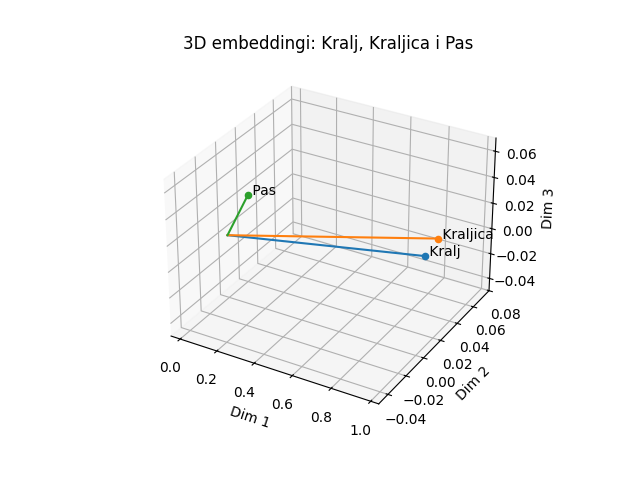

In [1]:
from Skripte.Vjezba12.zadatak1 import dot_product, plot_vectors_3d
import numpy as np

# Autoreload
%load_ext autoreload
%autoreload 2
%matplotlib widget

# Embeddingi (izmišljeni primjer)
Kralj = np.array([0.99, 0.01, 0.02], dtype=float)
Kraljica = np.array([0.97, 0.03, 0.02], dtype=float)
Pas = np.array([0.01, 0.02, 0.02], dtype=float)

# Alignment score (dot product)
score_kralj_kraljica = dot_product(Kralj, Kraljica)
score_kralj_pas = dot_product(Kralj, Pas)

# Ispis korak-po-korak (kao u tekstu)
print("Uzmimo embeddinge riječi Kralj i Kraljica:\n")
print(f"Kralj     = {Kralj.tolist()}")
print(f"Kraljica  = {Kraljica.tolist()}\n")

print("Alignment score (Kralj · Kraljica):")
print(f"(0.99 * 0.97) + (0.01 * 0.03) + (0.02 * 0.02) = {score_kralj_kraljica:.6f}\n")

print("Sada uzmimo embeddinge riječi Kralj i Pas:\n")
print(f"Kralj = {Kralj.tolist()}")
print(f"Pas   = {Pas.tolist()}\n")

print("Alignment score (Kralj · Pas):")
print(f"(0.99 * 0.01) + (0.01 * 0.02) + (0.02 * 0.02) = {score_kralj_pas:.6f}\n")

# 3D plot
vectors = {
    "Kralj": Kralj,
    "Kraljica": Kraljica,
    "Pas": Pas,
}
plot_vectors_3d(vectors, title="3D embeddingi: Kralj, Kraljica i Pas")

---
#### Normalizacija rezultata
Normaliziranje vrijednosti izlaza bilo koje neuronske mreže pomoću aktivacijske funkcije uobičajena je praksa. Rezultati poravnanja (*engl. alignment scores*) normalizirat će se pomoću aktivacijske funkcije **SoftMax** kako bi se dobile težine koje će se primijeniti na izvorne vektorske reprezentacije riječi. Podsjetimo se: funkcija SoftMax pretvara svaki rezultat poravnanja u probabilističku distribuciju tako da njihov zbroj iznosi jedan.

U našem primjeru:

- $S31 → SoftMax → W31$  
- $S32 → SoftMax → W32$  
- $S33 → SoftMax → W33$  
- $S34 → SoftMax → W34$ 

Sva četiri rezultata poravnanja prolaze kroz SoftMax kako bi se dobile konačne težine koje je potrebno primijeniti na izvorne vektorske reprezentacije riječi radi stvaranja konačne **kontekstualizirane reprezentacije riječi**.

> **Napomena:** Pojam „težine“ u ovom kontekstu **ne odnosi se** na parametre koje model uči tijekom treniranja.



---
<font color='red'>


## Zadatak

<left><img src="Images/Zadatak.png" width="70" height="70"/></left>
</font>

Za dane vektore povjerite normalizirane rezultate te uočite razlike u sakalrnim produktima. Što se dešava ako se računa sakalarni produkt $v1 \cdot v2$ te $v2 \ cdot v1$. Postoji li razlika? Koliko iznosi skalarni produkt vektoreske reprezentacije riječi same sa sobom ($v1 \cdot v1$)?

---

In [6]:
from Skripte.Vjezba12.zadatak1 import softmax_all_alignment_scores_torch
import numpy as np

# Autoreload
%load_ext autoreload
%autoreload 2

Kralj = np.array([0.99, 0.01, 0.02], dtype=float)
Kraljica = np.array([0.97, 0.03, 0.02], dtype=float)
Pas = np.array([0.01, 0.02, 0.02], dtype=float)

embeddings = {
    "Kralj": Kralj,
    "Kraljica": Kraljica,
    "Pas": Pas,
}

scores, weights = softmax_all_alignment_scores_torch(embeddings)

print("Alignment scores:")
for k, v in scores.items():
    print(f"{k}: {v:.6f}")

print("\nSoftMax attention weights (sum = 1):")
for k, v in weights.items():
    print(f"{k}: {v:.6f}")

print("\nSum of all weights:", sum(weights.values()))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Alignment scores:
('Kralj', 'Kralj'): 0.980600
('Kralj', 'Kraljica'): 0.961000
('Kralj', 'Pas'): 0.010500
('Kraljica', 'Kralj'): 0.961000
('Kraljica', 'Kraljica'): 0.942200
('Kraljica', 'Pas'): 0.010700
('Pas', 'Kralj'): 0.010500
('Pas', 'Kraljica'): 0.010700
('Pas', 'Pas'): 0.000900

SoftMax attention weights (sum = 1):
('Kralj', 'Kralj'): 0.171961
('Kralj', 'Kraljica'): 0.168624
('Kralj', 'Pas'): 0.065181
('Kraljica', 'Kralj'): 0.168624
('Kraljica', 'Kraljica'): 0.165483
('Kraljica', 'Pas'): 0.065194
('Pas', 'Kralj'): 0.065181
('Pas', 'Kraljica'): 0.065194
('Pas', 'Pas'): 0.064558

Sum of all weights: 0.9999999403953552


---
#### Ponovno ponderiranje izvornih vektorskih reprezentacija riječi

Sada se provodi završni proces ponovnog ponderiranja (*reweighing*). Kako bi se odredila ukupna količina pažnje koju riječ ($v3$) treba posvetiti ostalim riječima, dobivene težine množe se s pripadajućim izvornim vektorskim reprezentacijama riječi, a zatim se svi ti rezultati zbrajaju kako bi se dobio konačna vektorska reprezentacija riječi koja se uspoređuje ($v3$). U ovom slučaju:

- $W31 \cdot v1 = Y31$  
- $W32 \cdot v2 = Y32$  
- $W33 \cdot v3 = Y33$ 
- $W34 \cdot v4 = Y34$  

Zatim:

- $Y31 + Y32 + Y33 + Y34 = Y3$ 

Vektor *Y3* predstavlja konačnu, ponovno ponderiranu vektorsku reprezentaciju vektora $v3$. Treba imati na umu da su $Y31$, $Y32$, $Y33$ i $Y34$ svaki za sebe **vektori**, stoga ih je potrebno zbrojiti kako bi se dobio jedan jedinstveni završni vektor.

Važno je zapamtiti da se gore opisani postupak provodi i za svaku drugu riječ u rečenici.

---

#### Dodavanje težina

Intuitivno gledano, svi gore opisani postupci imaju smisla, osim jedne stvari: budući da **nema težina koje se uče**, rezultati poravnanja (*engl. alignment scores*) i težine self-attentiona u osnovi su unaprijed određeni te model neće moći naučiti dublje odnose između riječi. Upravo je to razlog zašto se u **self-attention blok uvode težine**.
  
Kako bi model mogao naučiti najdublje veze između riječi, težine će se uvesti na **tri mjesta**:

1. na ulazne vektorske reprezentacije riječi,  
2. u usporedbu sličnosti pomoću skalarnog produkta,  
3. u završni korak ponovnog ponderiranja vektorske reprezentacije riječi.  

Dodatna prednost uvođenja težina na ovim mjestima jest ta da se **oblik/dimenzionalnost vektora ne mijenja**. Naime, ako se vektor dimenzije $(1 \times k)$ pomnoži s matricom dimenzije $(k \times k)$, rezultat je ponovno vektor dimenzije $(1 \times k)$. Stoga, čak i nakon uvođenja težina, dimenzionalnost i oblik podataka ostaju isti.

Zbog toga težine se moraju uvesti upravo na mjestia gdje se koriste izvorna vektorska reprezentacija riječi $(v_1, v_2, v_3, v_4)$, jer svi oni imaju isti oblik. Čak i kada ih množimo s matricama težina dimenzije $(k \times k)$, rezultat ostaje vektor dimenzije $(1 \times k)$.

Tri su mjesta na kojima se koriste izvorne vektorske reprezentacije riječi:
- ulazni vektorske reprezentacije riječi,
- izračun sličnosti (*dot product*) prilikom usporedbe svake riječi s ostalima,
- završni proces ponovnog ponderiranja, kada se normalizirane težine množe s izvornim vektorskim reprezentacijama riječi.

Uz uvedene težine, izračuni sada izgledaju ovako:

- $(v_1 \cdot M_k) \cdot (v_3 \cdot M_q) = S_{31}$  
- $(v_2 \cdot M_k) \cdot (v_3 \cdot M_q) = S_{32}$ 
- $(v_3 \cdot M_k) \cdot (v_3 \cdot M_q) = S_{33}$ 
- $(v_4 \cdot M_k) \cdot (v_3 \cdot M_q) = S_{34}$

U ovom koraku se obično vrijednosti podjele/skaliraju sa $\sqrt{d}$ gdje je $d$ broj ulaznih riječi.

Zatim slijedi normalizacija:

- $S_{31} \rightarrow \text{SoftMax} \rightarrow W_{31}$  
- $S_{32} \rightarrow \text{SoftMax} \rightarrow W_{32}$  
- $S_{33} \rightarrow \text{SoftMax} \rightarrow W_{33}$  
- $S_{34} \rightarrow \text{SoftMax} \rightarrow W_{34}$

Prisjetmo se: $\text{SoftMax}(s_i) = \frac{e^{s_i}}{\sum_{j=1}^{n} e^{s_j}}$ pri čemu se radi stabilnosti izračuna prvo oduzme od svih vrijednosti maksimalna vrijednost.

Nakon toga dolazi završno ponderiranje embeddinga:

- $(v_1 \cdot M_v) \cdot W_{31} = Y_{31}$  
- $(v_2 \cdot M_v) \cdot W_{32} = Y_{32}$  
- $(v_3 \cdot M_v) \cdot W_{33} = Y_{33}$  
- $(v_4 \cdot M_v) \cdot W_{34} = Y_{34}$  

Na kraju:

- $Y_{31} + Y_{32} + Y_{33} + Y_{34} = Y_3$

Kao što se može vidjeti, svaki put kada se koriste izvorne vekotrske reprezentacije riječi $(v_1, v_2, v_3, v_4)$, ti vektori se množe s odgovarajućim matricama težina. Matrice $M_k$, $M_q$ i $M_v$ predstavljaju **key**, **query** i **value** matrice (težine) koje model uči tijekom treniranja.

Važno je zapamtiti da su u gore navedenim izračunima self-attention operacije prikazane samo za jednu riječ, $v_3$. U stvarnosti se taj postupak istovremeno provodi za sve riječi u rečenici korištenjem vektorizacije i linearne algebre.

> **Napomena:** U dijagramu i izračunima iznad, prilikom množenja key, query i value matrica s pripadajućim embedding vektorima koristi se **matrično množenje**, a ne skalarni (dot) produkt.
---

<font color='red'>


## Zadatak

<left><img src="Images/Zadatak.png" width="70" height="70"/></left>
</font>

Sljedeći programski kod implementira attention module. Proučite programski kod te navedite koliko parametara ima ovaj modul. 

In [10]:
from Skripte.Vjezba12.self_attention_module import SelfAttention, print_model_summary, plot_graph
import torch

# Autoreload
%load_ext autoreload
%autoreload 2
X = torch.tensor([[
    [0.99, 0.01, 0.02],  # Kralj
    [0.97, 0.03, 0.02],  # Kraljica
    [0.01, 0.02, 0.02],  # Pas
]], dtype=torch.float32) 

sa = SelfAttention(embed_dim=3, return_attention=True)
Y, A = sa(X)

print("Output Y shape:", Y.shape)     # (1, 3, 3)
print("Attention A shape:", A.shape)  # (1, 3, 3)
print("Attention matrix (A[0]):\n", A[0])

# Vaš kod ovdje
#print_model_summary(model = sa, input_dim = (1,3,3))
#plot_graph(model = sa, input_dim = (1,3,3))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Output Y shape: torch.Size([1, 3, 3])
Attention A shape: torch.Size([1, 3, 3])
Attention matrix (A[0]):
 tensor([[0.3465, 0.3467, 0.3067],
        [0.3461, 0.3463, 0.3076],
        [0.3343, 0.3340, 0.3317]], grad_fn=<SelectBackward0>)


In [11]:
from Skripte.Vjezba12.self_attention_widget import SelfAttentionDemoWidget

w = SelfAttentionDemoWidget()
w.display()

---

## Višeglava pažnja (*engl. Multi-Headed Attention*)

Iako se na prvi pogled može činiti razumnim da je jedan self-attention blok dovoljan kako bi riječ dobila kontekstualnu relevantnost, u praksi to često nije slučaj. Riječ vrlo često mora istovremeno posvetiti pažnju **više drugih riječi**, a jedan self-attention blok ponekad nije dovoljan kako bi se obuhvatili svi ti odnosi. To je posebno izraženo u primjerima gdje je ulazni tekst vrlo dugačak (npr. u zadacima sažimanja teksta).

Parovi riječi koji imaju kontekstualnu povezanost ponekad neće dobiti dovoljno pažnje da bi se uočila značajna promjena u njihovim vektorskim reprezentacijama.

Kako bi se taj problem riješio, koristi se **višeglavi attention blok** (*multi-headed attention*). Višeglavi attention blok proširuje sposobnost modela da se istovremeno fokusira na različite pozicije u ulaznom tekstu.

Višeglavi attention blok u osnovi je isti kao i standardni self-attention blok, ali umjesto samo jednog attention bloka, sastoji se od **više self-attention blokova koji rade paralelno**. Ti self-attention blokovi **ne dijele težine**; jedino što im je zajedničko jesu isti ulazne vektorske reprezentacije riječi. Broj self-attention blokova u višeglavom attention bloku predstavlja **hiperparametar modela**.

Pretpostavimo da se koristi $n$ self-attention blokova. Kao posljedica toga, nakon što svaki self-attention blok izvrši vlastite izračune, za svaku riječ dobit ćemo $n$ različitih vektorskih reprezentacija. Kako bi se zadržala samo jedna vektorska reprezentacija, višeglavi attention blok **konkatenira** (spaja) sve dobivene vektorske reprezentacije i zatim ih prosljeđuje kroz **gusto povezani (dense) sloj**.

Treba imati na umu da je tendencija takva da **oblik i broj izlaza odgovaraju obliku i broju ulaza**. Budući da su vektorske reprezentacije konkatenirane, broj ulaznih elemenata se povećava, a prolaskom kroz dense sloj omogućuje se kontrola izlazne dimenzionalnosti. Na taj se način osigurava da je oblik izlaza jednak obliku ulaznih vektorskih reprezentacija.

---
<font color='red'>


## Zadatak

<left><img src="Images/Zadatak.png" width="70" height="70"/></left>
</font>

Za dane vektore povjerite broj parametara multi_head_self_attention_sloja te odgovorite na pitanje koliko parametara će imati modul sa $n =5$ glava. Do kojeg problema dolazi? Za koliko svaka glava povećva broj parametra: primjerice broj parametara modela sa $1$ i sa $3$ glave? Nastojite razumjeti ovu problematiku.

---

In [34]:
from Skripte.Vjezba12.multihead_self_attention_module import MultiHeadSelfAttention, print_model_summary, plot_graph
import torch

# Autoreload
%load_ext autoreload
%autoreload 2
X = torch.tensor([[
    [0.99, 0.01, 0.02],  # Kralj
    [0.97, 0.03, 0.02],  # Kraljica
    [0.01, 0.02, 0.02],  # Pas
]], dtype=torch.float32) 


mha = MultiHeadSelfAttention(embed_dim=3, num_heads=3, return_attention=True)
Y, A = mha(X)

print(Y.shape)  # torch.Size([2, 5, 32])
print(A.shape)  # torch.Size([2, 4, 5, 5])
    
# Vaš kod ovdje
print_model_summary(model = mha, input_dim = (1,3,3))
#plot_graph(model = sa, input_dim = (1,3,3))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
torch.Size([1, 3, 3])
torch.Size([1, 3, 3, 3])


Layer (type (var_name))                            Input Shape      Output Shape     Param #          Trainable
MultiHeadSelfAttention (MultiHeadSelfAttention)    [1, 3, 3]        [1, 3, 3]        --               True
├─Linear (W_q)                                     [1, 3, 3]        [1, 3, 3]        12               True
├─Linear (W_k)                                     [1, 3, 3]        [1, 3, 3]        12               True
├─Linear (W_v)                                     [1, 3, 3]        [1, 3, 3]        12               True
├─Dropout (attn_dropout)                           [1, 3, 3, 3]     [1, 3, 3, 3]     --               --
├─Linear (W_o)                                     [1, 3, 3]        [1, 3, 3]        12               True
├─Dropout (proj_dropout)                           [1, 3, 3]        [1, 3, 3]        --               --
Total params: 48
Trainable params: 48
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pa

In [ ]:
from Skripte.Vjezba11.widget import unified_mlp_conv2d_widget
from IPython.display import display

# Autoreload
%load_ext autoreload
%autoreload 2

display(unified_mlp_conv2d_widget())